# LAB 02 - N-gram Language Models

Notebook này cài đặt và chạy unigram/bigram/trigram từ count, so sánh MLE với Laplace, đo perplexity, dự đoán từ tiếp theo và xếp hạng continuation.

**Phạm vi:** 10.000 C4 documents, seed 42, split theo document 80/10/10. Vocabulary chỉ học từ train (`min_count=2`, tối đa 50.000 token kể cả `</s>` và `<unk>`).

> **Academic integrity:** Theo mục 25 của đề, phần calculation ban đầu, prediction trước experiment, giải thích kết quả, error analysis, reflection và individual learning check phải do sinh viên tự làm, không dùng AI. Notebook chỉ sinh số liệu/bằng chứng; các ô phân tích bị cấm không được viết hộ.

In [1]:
from __future__ import annotations

import gc
import gzip
import json
import math
import random
import re
import time
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ngram_lm import BOS, EOS, UNK, NGramLanguageModel, build_vocabulary

SEED = 42
MAX_DOCUMENTS = 10_000
TRAIN_RATIO = 0.80
VALID_RATIO = 0.10
MIN_COUNT = 2
MAX_VOCAB_SIZE = 50_000

random.seed(SEED)
np.random.seed(SEED)

LAB_DIR = Path.cwd()
DATA_PATH = LAB_DIR.parent / "c4-train.00000-of-01024-30K.json.gz"
assert DATA_PATH.exists(), f"Không tìm thấy corpus: {DATA_PATH}"

print(f"Corpus: {DATA_PATH.name}")
print(f"Configuration: docs={MAX_DOCUMENTS:,}, seed={SEED}, split=80/10/10")

Corpus: c4-train.00000-of-01024-30K.json.gz
Configuration: docs=10,000, seed=42, split=80/10/10


## 1. Đọc corpus, tokenization và train/validation/test split

In [2]:
TOKEN_PATTERN = re.compile(r"[a-z]+(?:'[a-z]+)?|[0-9]+(?:[.,][0-9]+)?")
SENTENCE_SPLIT_PATTERN = re.compile(r"(?<=[.!?])\s+|\n+")


def tokenize(text: str) -> list[str]:
    """Lowercase English-oriented tokenizer used consistently in all splits."""
    return TOKEN_PATTERN.findall(text.lower())


def document_to_sentences(text: str) -> list[list[str]]:
    sentences = []
    for segment in SENTENCE_SPLIT_PATTERN.split(text):
        tokens = tokenize(segment)
        if tokens:
            sentences.append(tokens)
    return sentences


def load_documents(path: Path, limit: int) -> list[str]:
    documents = []
    with gzip.open(path, "rt", encoding="utf-8") as stream:
        for line in stream:
            item = json.loads(line)
            text = item.get("text", "").strip()
            if text:
                documents.append(text)
            if len(documents) >= limit:
                break
    return documents


start = time.perf_counter()
documents = load_documents(DATA_PATH, MAX_DOCUMENTS)
random.Random(SEED).shuffle(documents)

n_train = int(len(documents) * TRAIN_RATIO)
n_valid = int(len(documents) * VALID_RATIO)
train_docs = documents[:n_train]
valid_docs = documents[n_train:n_train + n_valid]
test_docs = documents[n_train + n_valid:]

train_sentences = [s for doc in train_docs for s in document_to_sentences(doc)]
valid_sentences = [s for doc in valid_docs for s in document_to_sentences(doc)]
test_sentences = [s for doc in test_docs for s in document_to_sentences(doc)]

split_stats = pd.DataFrame([
    {"split": "train", "documents": len(train_docs), "sentences": len(train_sentences),
     "tokens": sum(map(len, train_sentences))},
    {"split": "validation", "documents": len(valid_docs), "sentences": len(valid_sentences),
     "tokens": sum(map(len, valid_sentences))},
    {"split": "test", "documents": len(test_docs), "sentences": len(test_sentences),
     "tokens": sum(map(len, test_sentences))},
])

del documents, train_docs, valid_docs, test_docs
gc.collect()

print(f"Loaded and tokenized in {time.perf_counter() - start:.2f}s")
display(split_stats)
print("TOTAL:", split_stats[["documents", "sentences", "tokens"]].sum().to_dict())

Loaded and tokenized in 4.19s


,split,documents,sentences,tokens
0,train,8000,166282,2917540
1,validation,1000,21471,378409
2,test,1000,20201,370268


TOTAL: {'documents': 10000, 'sentences': 207954, 'tokens': 3666217}


## 2. Xây vocabulary và train ba mô hình

In [3]:
start = time.perf_counter()
vocabulary = build_vocabulary(
    train_sentences,
    min_count=MIN_COUNT,
    max_size=MAX_VOCAB_SIZE,
)
print(f"Vocabulary size (train only): {len(vocabulary):,}")
print(f"Contains EOS={EOS in vocabulary}, UNK={UNK in vocabulary}, BOS predicted={BOS in vocabulary}")

models = {}
for n, name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
    model_start = time.perf_counter()
    models[name] = NGramLanguageModel(n, vocabulary=vocabulary).fit(train_sentences)
    print(
        f"{name:8s}: {len(models[name].ngram_counts):>10,} unique n-grams "
        f"({time.perf_counter() - model_start:.2f}s)"
    )

unigram = models["Unigram"]
bigram = models["Bigram"]
trigram = models["Trigram"]
print(f"Total training time: {time.perf_counter() - start:.2f}s")

Vocabulary size (train only): 47,482
Contains EOS=True, UNK=True, BOS predicted=False


Unigram :     47,482 unique n-grams (3.93s)


Bigram  :    968,989 unique n-grams (6.37s)


Trigram :  2,112,386 unique n-grams (8.00s)
Total training time: 19.18s


## 3. Experiment 1 - Corpus statistics và frequency distribution

,model,unique_ngrams,hapax_ngrams,hapax_percent
0,Unigram,47482,0,0.00%
1,Bigram,968989,683894,70.58%
2,Trigram,2112386,1841994,87.20%


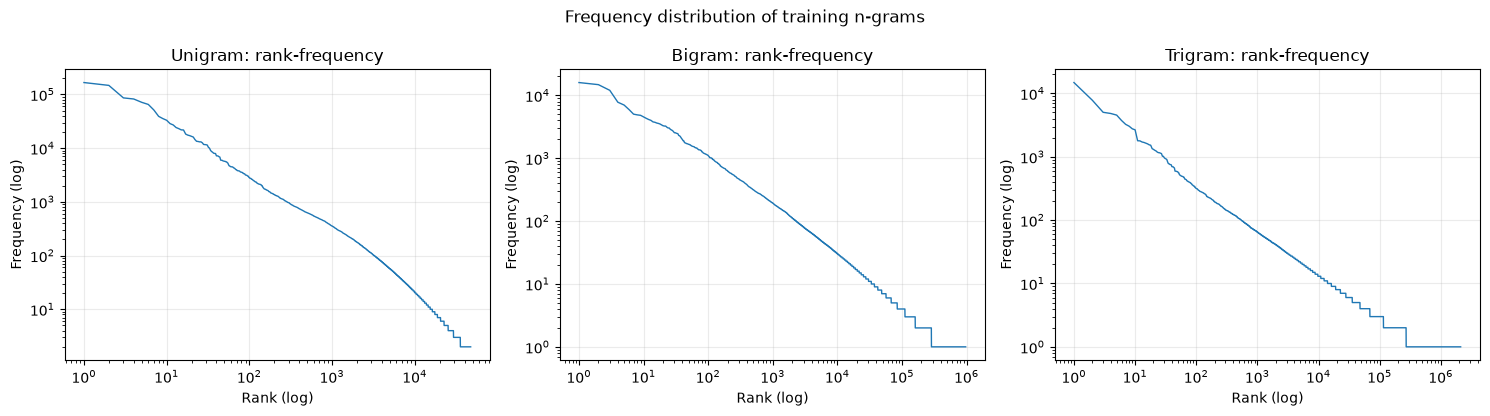

In [4]:
ngram_stats = pd.DataFrame([
    {
        "model": name,
        "unique_ngrams": len(model.ngram_counts),
        "hapax_ngrams": sum(count == 1 for count in model.ngram_counts.values()),
        "hapax_percent": 100 * sum(count == 1 for count in model.ngram_counts.values()) / len(model.ngram_counts),
    }
    for name, model in models.items()
])
display(ngram_stats.style.format({"hapax_percent": "{:.2f}%"}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for axis, (name, model) in zip(axes, models.items()):
    frequencies = np.array(sorted(model.ngram_counts.values(), reverse=True))
    ranks = np.arange(1, len(frequencies) + 1)
    axis.loglog(ranks, frequencies, linewidth=1.0)
    axis.set_title(f"{name}: rank-frequency")
    axis.set_xlabel("Rank (log)")
    axis.set_ylabel("Frequency (log)")
    axis.grid(alpha=0.25)
fig.suptitle("Frequency distribution of training n-grams")
fig.tight_layout()
plt.show()

## 4. Sanity checks cho implementation

In [5]:
toy = [["a", "b"], ["a", "c"]]
toy_vocab = build_vocabulary(toy, min_count=1, max_size=None)
toy_bigram = NGramLanguageModel(2, vocabulary=toy_vocab).fit(toy)

# Với Laplace, phân phối trên toàn vocabulary phải chuẩn hóa thành 1.
laplace_sum = sum(toy_bigram.probability(["a"], word, "laplace") for word in toy_vocab)
assert math.isclose(laplace_sum, 1.0, rel_tol=1e-12, abs_tol=1e-12)

# exp(log P) và P trực tiếp phải khớp trên câu ngắn.
p_direct = toy_bigram.sentence_probability(["a", "b"], "laplace")
p_from_log = math.exp(toy_bigram.sentence_log_probability(["a", "b"], "laplace"))
assert math.isclose(p_direct, p_from_log, rel_tol=1e-12)

# MLE của một bigram chưa thấy phải bằng 0; Laplace phải dương.
assert toy_bigram.probability(["b"], "c", "mle") == 0.0
assert toy_bigram.probability(["b"], "c", "laplace") > 0.0

print("All sanity checks passed.")
print(f"Laplace normalization for context 'a': {laplace_sum:.12f}")
print(f"P(['a', 'b']) = exp(log P) = {p_direct:.12g}")

All sanity checks passed.
Laplace normalization for context 'a': 1.000000000000
P(['a', 'b']) = exp(log P) = 0.0408163265306


### Vì sao dùng log probability?

Máy tính có độ chính xác hữu hạn; tích rất nhiều xác suất nhỏ có thể bị làm tròn thành 0 (numerical underflow). Cộng log biến tích thành tổng và giữ giá trị trong miền số biểu diễn ổn định hơn. Đây là giải thích kỹ thuật của implementation; phần reflection cá nhân vẫn phải do sinh viên tự viết.

## 5. Experiment 2 & 3 - MLE, Laplace và perplexity

In [6]:
splits = {
    "train": train_sentences,
    "validation": valid_sentences,
    "test": test_sentences,
}

perplexity_rows = []
eval_start = time.perf_counter()
for model_name, model in models.items():
    for smoothing in ["mle", "laplace"]:
        for split_name, sentences in splits.items():
            start_one = time.perf_counter()
            value = model.corpus_perplexity(sentences, smoothing=smoothing)
            perplexity_rows.append({
                "model": model_name,
                "smoothing": smoothing.upper(),
                "split": split_name,
                "perplexity": value,
            })
            shown = "inf" if math.isinf(value) else f"{value:.4f}"
            print(f"{model_name:8s} {smoothing:7s} {split_name:10s}: {shown:>12s} "
                  f"({time.perf_counter() - start_one:.2f}s)")

perplexity_long = pd.DataFrame(perplexity_rows)
perplexity_table = perplexity_long.pivot_table(
    index=["model", "smoothing"], columns="split", values="perplexity", aggfunc="first"
).reset_index()

print(f"Evaluation time: {time.perf_counter() - eval_start:.2f}s")
display(perplexity_table.style.format({
    "train": lambda x: "inf" if math.isinf(x) else f"{x:.4f}",
    "validation": lambda x: "inf" if math.isinf(x) else f"{x:.4f}",
    "test": lambda x: "inf" if math.isinf(x) else f"{x:.4f}",
}))

Unigram  mle     train     :    1413.9179 (4.68s)


Unigram  mle     validation:    1232.0013 (0.56s)


Unigram  mle     test      :    1180.4553 (0.55s)


Unigram  laplace train     :    1415.8185 (4.77s)


Unigram  laplace validation:    1236.3986 (0.62s)


...

Trigram  mle     train     :       9.9304 (7.77s)
Trigram  mle     validation:          inf (0.00s)
Trigram  mle     test      :          inf (0.00s)


Trigram  laplace train     :   11530.4715 (8.26s)


Trigram  laplace validation:   19334.2761 (1.11s)


Trigram  laplace test      :   19000.2524 (1.33s)
Evaluation time: 46.09s


split,model,smoothing,test,train,validation
0,Bigram,LAPLACE,3469.0762,3003.5518,3636.8735
1,Bigram,MLE,inf,125.1845,inf
2,Trigram,LAPLACE,19000.2524,11530.4715,19334.2761
3,Trigram,MLE,inf,9.9304,inf
4,Unigram,LAPLACE,1185.0380,1415.8185,1236.3986
5,Unigram,MLE,1180.4553,1413.9179,1232.0013


**Sinh viên tự giải thích kết quả (không dùng AI):**

- Dùng số liệu cụ thể trong bảng để nói training perplexity thay đổi ra sao.
- Kiểm tra validation/test có cải thiện cùng chiều hay không.
- Liên hệ với số unique/hapax n-gram và unseen events.
- Khi nói overfitting, phải đối chiếu train với validation/test; không suy luận chỉ từ một split.
- Chỉ so sánh các hàng có cùng preprocessing, vocabulary và cách đếm `</s>`.

Viết phần giải thích cuối cùng bằng lời của bạn trong deliverable phù hợp; notebook không tạo hộ đoạn trả lời này.

## 6. Application - Next-word prediction

In [7]:
# Thu thập nhiều context trigram thật từ test, rồi quét bảng count đúng một lần.
candidate_records = []
seen_contexts = set()
for sentence in test_sentences:
    mapped = [token if token in vocabulary else UNK for token in sentence]
    for i in range(2, len(mapped)):
        history = tuple(mapped[i - 2:i])
        actual = mapped[i]
        if UNK in history or actual in {UNK, EOS, BOS}:
            continue
        if history not in seen_contexts:
            candidate_records.append({"context_tuple": history, "actual": actual})
            seen_contexts.add(history)
        if len(candidate_records) >= 2_000:
            break
    if len(candidate_records) >= 2_000:
        break

requested = {row["context_tuple"] for row in candidate_records}
observed_by_context = defaultdict(list)
for gram, count in trigram.ngram_counts.items():
    history, word = gram[:-1], gram[-1]
    if history in requested and word not in {BOS, EOS, UNK}:
        observed_by_context[history].append((word, count))

prediction_candidates = []
for row in candidate_records:
    history = row["context_tuple"]
    observed = sorted(observed_by_context.get(history, []), key=lambda x: (-x[1], x[0]))[:5]
    if not observed:
        continue
    top_predictions = [
        (word, trigram.probability(history, word, "laplace"))
        for word, _ in observed
    ]
    prediction_candidates.append({
        "context": " ".join(history),
        "prediction": top_predictions[0][0],
        "actual": row["actual"],
        "correct": top_predictions[0][0] == row["actual"],
        "probability": top_predictions[0][1],
        "context_count": trigram.context_counts[history],
        "top5": top_predictions,
    })

correct_cases = sorted(
    [row for row in prediction_candidates if row["correct"]],
    key=lambda row: (-row["context_count"], row["context"]),
)
wrong_cases = sorted(
    [row for row in prediction_candidates if not row["correct"]],
    key=lambda row: (-row["context_count"], row["context"]),
)
selected_predictions = correct_cases[:2] + wrong_cases[:3]
if len(selected_predictions) < 5:
    selected_predictions += prediction_candidates[: 5 - len(selected_predictions)]

prediction_table = pd.DataFrame([
    {
        "context": row["context"],
        "top_prediction": row["prediction"],
        "actual_next_word": row["actual"],
        "correct": row["correct"],
        "training_context_count": row["context_count"],
        "top_probability": row["probability"],
        "top_5": ", ".join(f"{word} ({prob:.4g})" for word, prob in row["top5"]),
    }
    for row in selected_predictions
])

print(f"Candidate pool: {len(prediction_candidates):,}; correct={len(correct_cases):,}; wrong={len(wrong_cases):,}")
display(prediction_table.style.format({"top_probability": "{:.6f}"}))

Candidate pool: 1,321; correct=194; wrong=1,127


,context,top_prediction,actual_next_word,correct,training_context_count,top_probability,top_5
0,to be,a,a,True,4010,0.006972,"a (0.006972), the (0.003185), able (0.003068), in (0.001185), used (0.001068)"
1,to make,a,a,True,1473,0.004147,"a (0.004147), sure (0.003902), the (0.003411), it (0.001981), your (0.001593)"
2,of the,most,property,False,16016,0.005055,"most (0.005055), best (0.002866), world (0.002583), year (0.002126), time (0.001638)"
3,in the,world,area,False,12047,0.004452,"world (0.004452), past (0.002973), first (0.002184), united (0.002049), future (0.002016)"
4,to the,right,property,False,7024,0.001156,"right (0.001156), next (0.001009), public (0.0009907), new (0.000899), world (0.000899)"


### Candidate cho error analysis cá nhân

Bảng trên cố ý gồm ít nhất hai dự đoán đúng và các dự đoán sai khi corpus cho phép. Sinh viên tự chọn 2 đúng + 2 sai, tra count và viết nguyên nhân trong `error_analysis.md`. Không dùng đoạn phân tích do AI tạo.

## 7. Application - Sentence ranking

In [8]:
ranking_context = tokenize("machine learning")
candidate_texts = {
    "A": "is useful for NLP",
    "B": "banana computer quickly",
    "C": "studies language models",
}

ranking_rows = []
for label, text in candidate_texts.items():
    continuation = tokenize(text)
    log_probability, length = trigram.continuation_log_probability(
        ranking_context, continuation, smoothing="laplace"
    )
    average_log_probability = log_probability / length
    ranking_rows.append({
        "candidate": label,
        "text": text,
        "token_count": length,
        "log_probability": log_probability,
        "average_log_probability": average_log_probability,
        "conditional_perplexity": math.exp(-average_log_probability),
    })

# Do độ dài candidate khác nhau, xếp hạng bằng average log-probability.
ranking_table = pd.DataFrame(ranking_rows).sort_values(
    "average_log_probability", ascending=False
).reset_index(drop=True)
ranking_table.insert(0, "rank", np.arange(1, len(ranking_table) + 1))
display(ranking_table.style.format({
    "log_probability": "{:.6f}",
    "average_log_probability": "{:.6f}",
    "conditional_perplexity": "{:.4f}",
}))

,rank,candidate,text,token_count,log_probability,average_log_probability,conditional_perplexity
0,1,A,is useful for NLP,4,-40.676929,-10.169232,26088.0375
1,2,B,banana computer quickly,3,-32.305181,-10.768394,47495.6627
2,3,C,studies language models,3,-32.305181,-10.768394,47495.6627


**Ghi chú phương pháp:** Total probability thiên về candidate ngắn vì mỗi thừa số xác suất không vượt quá 1. Vì ba candidate có số token khác nhau, bảng xếp hạng theo average log-probability (tương đương conditional perplexity) và vẫn hiển thị total log-probability để minh bạch. Sinh viên tự giải thích vì sao thứ hạng cụ thể xuất hiện.

## 8. Evidence cho Error analysis - Mục 22

In [9]:
error_evidence_rows = []
for row in selected_predictions:
    history = tuple(row["context"].split())
    predicted = row["prediction"]
    expected = row["actual"]
    predicted_count = trigram.ngram_counts[history + (predicted,)]
    expected_count = trigram.ngram_counts[history + (expected,)]
    error_evidence_rows.append({
        "context": row["context"],
        "model_prediction": predicted,
        "expected": expected,
        "correct": predicted == expected,
        "training_context_count": trigram.context_counts[history],
        "predicted_ngram_count": predicted_count,
        "expected_ngram_count": expected_count,
        "predicted_probability": trigram.probability(history, predicted, "laplace"),
        "expected_probability": trigram.probability(history, expected, "laplace"),
        "expected_was_unseen": expected_count == 0,
    })

error_evidence = pd.DataFrame(error_evidence_rows)
display(error_evidence.style.format({
    "predicted_probability": "{:.8f}",
    "expected_probability": "{:.8f}",
}))

,context,model_prediction,expected,correct,training_context_count,predicted_ngram_count,expected_ngram_count,predicted_probability,expected_probability,expected_was_unseen
0,to be,a,a,True,4010,358,358,0.00697196,0.00697196,False
1,to make,a,a,True,1473,202,202,0.00414667,0.00414667,False
2,of the,most,property,False,16016,320,34,0.00505528,0.00055120,False
3,in the,world,area,False,12047,264,84,0.00445161,0.00142788,False
4,to the,right,property,False,7024,62,7,0.00115584,0.00014677,False


Bảng này chỉ cung cấp bằng chứng định lượng. Sinh viên tự chọn 2 dòng đúng và 2 dòng sai, rồi tự xác định nguyên nhân trong `error_analysis.md`; notebook không viết hộ phần phân tích.

## 9. Evidence cho Context length - Mục 23

In [10]:
def unseen_event_statistics(model, sentences):
    total_events = 0
    unseen_events = 0
    for sentence in sentences:
        for context, word in model._sentence_events(sentence):
            total_events += 1
            unseen_events += model.ngram_counts[context + (word,)] == 0
    return total_events, unseen_events


unseen_rows = []
for model_name, model in models.items():
    for split_name, sentences in splits.items():
        total_events, unseen_events = unseen_event_statistics(model, sentences)
        unseen_rows.append({
            "model": model_name,
            "split": split_name,
            "total_events": total_events,
            "unseen_events": unseen_events,
            "unseen_rate": unseen_events / total_events,
        })

unseen_table = pd.DataFrame(unseen_rows)

ppl_wide = perplexity_long.pivot(
    index="model", columns=["smoothing", "split"], values="perplexity"
).reset_index()
ppl_wide.columns = [
    "model" if column[0] == "model" else f"{column[0].lower()}_{column[1]}_ppl"
    for column in ppl_wide.columns
]

unseen_wide = unseen_table.pivot(
    index="model", columns="split", values="unseen_rate"
).reset_index().rename(columns={
    "train": "train_unseen_rate",
    "validation": "validation_unseen_rate",
    "test": "test_unseen_rate",
})

context_length_summary = (
    ngram_stats
    .merge(ppl_wide, on="model")
    .merge(unseen_wide, on="model")
)

display(unseen_table.style.format({"unseen_rate": "{:.2%}"}))
display(context_length_summary.style.format({
    "hapax_percent": "{:.2f}%",
    "train_unseen_rate": "{:.2%}",
    "validation_unseen_rate": "{:.2%}",
    "test_unseen_rate": "{:.2%}",
    **{column: (lambda value: "inf" if math.isinf(value) else f"{value:.4f}")
       for column in context_length_summary.columns if column.endswith("_ppl")},
}))

,model,split,total_events,unseen_events,unseen_rate
0,Unigram,train,3083822,0,0.00%
1,Unigram,validation,399880,0,0.00%
2,Unigram,test,390469,0,0.00%
3,Bigram,train,3083822,0,0.00%
4,Bigram,validation,399880,96982,24.25%
5,Bigram,test,390469,91860,23.53%
6,Trigram,train,3083822,0,0.00%
7,Trigram,validation,399880,256212,64.07%
8,Trigram,test,390469,247396,63.36%


,model,unique_ngrams,hapax_ngrams,hapax_percent,mle_train_ppl,mle_validation_ppl,mle_test_ppl,laplace_train_ppl,laplace_validation_ppl,laplace_test_ppl,test_unseen_rate,train_unseen_rate,validation_unseen_rate
0,Unigram,47482,0,0.00%,1413.9179,1232.0013,1180.4553,1415.8185,1236.3986,1185.0380,0.00%,0.00%,0.00%
1,Bigram,968989,683894,70.58%,125.1845,inf,inf,3003.5518,3636.8735,3469.0762,23.53%,0.00%,24.25%
2,Trigram,2112386,1841994,87.20%,9.9304,inf,inf,11530.4715,19334.2761,19000.2524,63.36%,0.00%,64.07%


Dùng bảng tổng hợp để tự trả lời: context dài hơn có luôn tốt hơn không? Phải đối chiếu đồng thời train/validation/test perplexity, số unique n-gram, tỷ lệ hapax và unseen rate. Không suy luận chỉ từ training perplexity.

## 10. Lưu toàn bộ kết quả máy sinh ra

In [11]:
corpus_result_rows = []
for _, row in split_stats.iterrows():
    corpus_result_rows.append({
        "record_type": "corpus_split",
        "split": row["split"],
        "documents": row["documents"],
        "sentences": row["sentences"],
        "tokens": row["tokens"],
    })
for _, row in ngram_stats.iterrows():
    corpus_result_rows.append({
        "record_type": "ngram_statistics",
        "model": row["model"],
        "unique_ngrams": row["unique_ngrams"],
        "hapax_ngrams": row["hapax_ngrams"],
        "hapax_percent": row["hapax_percent"],
    })

perplexity_result = perplexity_long.copy()
perplexity_result.insert(0, "record_type", "perplexity")

prediction_result = prediction_table.copy()
prediction_result.insert(0, "record_type", "next_word")

ranking_result = ranking_table.copy()
ranking_result.insert(0, "record_type", "sentence_ranking")

error_result = error_evidence.copy()
error_result.insert(0, "record_type", "error_evidence")

unseen_result = unseen_table.copy()
unseen_result.insert(0, "record_type", "unseen_events")

context_length_result = context_length_summary.copy()
context_length_result.insert(0, "record_type", "context_length_summary")

results = pd.concat(
    [
        pd.DataFrame(corpus_result_rows),
        perplexity_result,
        prediction_result,
        ranking_result,
        error_result,
        unseen_result,
        context_length_result,
    ],
    ignore_index=True,
    sort=False,
)
RESULTS_PATH = LAB_DIR / "results.csv"
results.to_csv(RESULTS_PATH, index=False, encoding="utf-8-sig")

print(f"Saved {len(results)} rows to {RESULTS_PATH}")
display(results.head(12))

Saved 49 rows to C:\Users\Acer\Documents\NLP\lab02\results.csv


,record_type,split,documents,sentences,tokens,model,unique_ngrams,hapax_ngrams,hapax_percent,smoothing,...,unseen_rate,mle_train_ppl,mle_validation_ppl,mle_test_ppl,laplace_train_ppl,laplace_validation_ppl,laplace_test_ppl,test_unseen_rate,train_unseen_rate,validation_unseen_rate
0,corpus_split,train,8000.0,166282.0,2917540.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,corpus_split,validation,1000.0,21471.0,378409.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,corpus_split,test,1000.0,20201.0,370268.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ngram_statistics,NaN,NaN,NaN,NaN,Unigram,47482.0,0.0,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ngram_statistics,NaN,NaN,NaN,NaN,Bigram,968989.0,683894.0,70.578097,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ngram_statistics,NaN,NaN,NaN,NaN,Trigram,2112386.0,1841994.0,87.199688,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,perplexity,train,NaN,NaN,NaN,Unigram,NaN,NaN,NaN,MLE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,perplexity,validation,NaN,NaN,NaN,Unigram,NaN,NaN,NaN,MLE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,perplexity,test,NaN,NaN,NaN,Unigram,NaN,NaN,NaN,MLE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,perplexity,train,NaN,NaN,NaN,Unigram,NaN,NaN,NaN,LAPLACE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 11. AI assistance statement

**Tool:** OpenAI Codex  
**Purpose:** triển khai/kiểm tra code n-gram, chạy thí nghiệm, visualization, lưu output.  
**Generated:** module `ngram_lm.py`, notebook pipeline, tables/plots, prediction/ranking code.  
**Modified:** cấu hình 10K documents, split 80/10/10, train-only vocabulary, `<unk>`/boundary handling.  
**Verified:** sanity checks, chạy toàn bộ notebook không lỗi, kiểm tra `results.csv` và output đã được lưu.

Chi tiết và cảnh báo chính sách môn học nằm trong `AI_ASSISTANCE.md`.